In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import os
from tqdm import tqdm
from PIL import Image
from collections import Counter
import numpy as np
import seaborn as sns

In [ ]:
torch.__version__

'2.6.0+cu124'

In [ ]:
torch.cuda.is_available()

True

In [ ]:
torch.cuda.device_count()

1

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/Solar_Dataset'
os.listdir(dataset_path)

['Electrical-damage',
 'Physical-Damage',
 'Snow-Covered',
 'Dusty',
 'Clean',
 'Bird-drop']

In [ ]:
img_size = 224
batch_size = 32

In [ ]:
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
dataset = torchvision.datasets.ImageFolder(root=dataset_path, transform=transform)
class_names = dataset.classes

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)

In [ ]:
from torchvision.models import (
    resnet18, ResNet18_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    efficientnet_b0, EfficientNet_B0_Weights
)

def get_model(name, num_classes):
    if name == "resnet18":
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "mobilenet_v2":
        weights = MobileNet_V2_Weights.DEFAULT
        model = mobilenet_v2(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT
        model = efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    else:
        raise ValueError("Unsupported model")

    return model


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
dataset = ImageFolder(root=dataset_path)

# Get class names and mapping
class_names = dataset.classes
class_to_idx = dataset.class_to_idx

print("Classes:", class_names)
print("Class to index mapping:", class_to_idx)
print("Total images:", len(dataset))

🔢 Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
🔁 Class to index mapping: {'Bird-drop': 0, 'Clean': 1, 'Dusty': 2, 'Electrical-damage': 3, 'Physical-Damage': 4, 'Snow-Covered': 5}
🖼️ Total images: 885


In [ ]:
models_to_train = ["resnet18", "mobilenet_v2", "efficientnet_b0"]

In [ ]:
for model_name in models_to_train:
    print(f"\n Training model: {model_name}")

    # Load model
    model = get_model(model_name, len(class_names)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    # Train
    for epoch in range(5):  # Change epoch as needed
        model.train()
        total_loss = 0
        for imgs, labels in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f" {model_name} Epoch {epoch+1}, Loss: {total_loss:.4f}")

    # Save Model
    save_path = f"/content/drive/MyDrive/{model_name}_solarguard.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Model saved: {save_path}")


 Training model: resnet18


resnet18 Epoch 1: 100%|██████████| 23/23 [00:19<00:00,  1.16it/s]


 resnet18 Epoch 1, Loss: 22.5762


resnet18 Epoch 2: 100%|██████████| 23/23 [00:20<00:00,  1.12it/s]


 resnet18 Epoch 2, Loss: 6.0157


...

 efficientnet_b0 Epoch 3, Loss: 18.9623


efficientnet_b0 Epoch 4: 100%|██████████| 23/23 [00:21<00:00,  1.05it/s]


 efficientnet_b0 Epoch 4, Loss: 12.5989


efficientnet_b0 Epoch 5: 100%|██████████| 23/23 [00:20<00:00,  1.11it/s]


 efficientnet_b0 Epoch 5, Loss: 8.8319
💾 Model saved: /content/drive/MyDrive/efficientnet_b0_solarguard.pth


                   precision    recall  f1-score   support

        Bird-drop       0.73      0.90      0.81        40
            Clean       0.93      0.82      0.87        45
            Dusty       0.74      0.67      0.70        30
Electrical-damage       0.62      0.94      0.75        16
  Physical-Damage       1.00      0.45      0.62        20
     Snow-Covered       0.89      0.96      0.93        26

         accuracy                           0.80       177
        macro avg       0.82      0.79      0.78       177
     weighted avg       0.83      0.80      0.80       177



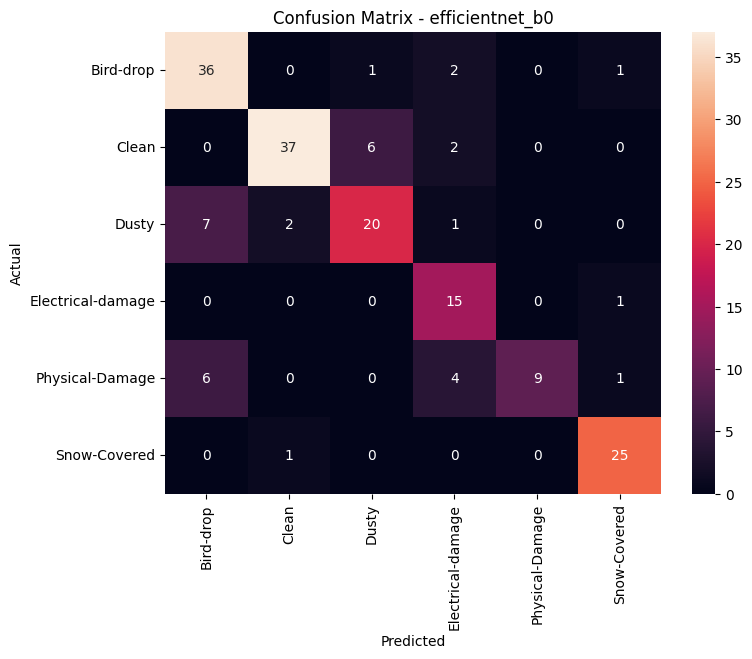

In [ ]:
def evaluate(model):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

evaluate(model)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(model_name, num_classes=6):
    if model_name == "resnet18":
        model = models.resnet18(weights=None)
        model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=None)
        model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)
    else:
        raise ValueError("Invalid model name.")

    model.load_state_dict(torch.load(f"/content/drive/MyDrive/{model_name}_solarguard.pth", map_location=device))
    model.to(device)
    model.eval()
    return model


In [ ]:
# Define the same transforms used during validation
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load validation dataset
val_dataset = ImageFolder(dataset_path, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

def evaluate_model(model, dataloader):
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total


In [ ]:
model_names = ["resnet18", "mobilenet_v2", "efficientnet_b0"]
results = {}

for name in model_names:
    model = load_model(name, num_classes=6)
    accuracy = evaluate_model(model, val_loader)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")


✅ resnet18 Accuracy: 0.5887
✅ mobilenet_v2 Accuracy: 0.7548
✅ efficientnet_b0 Accuracy: 0.7684


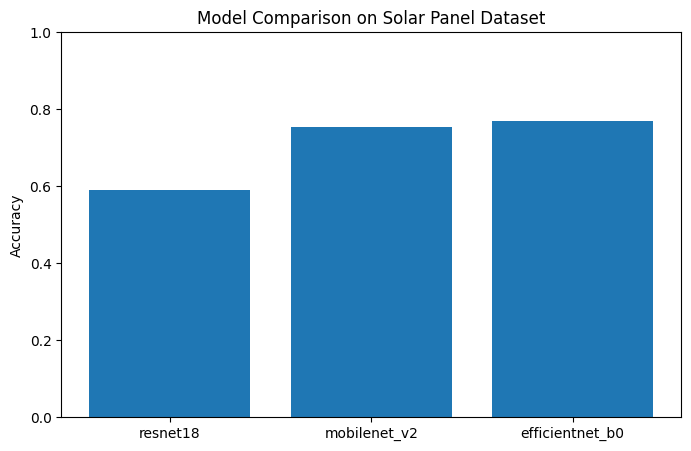

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Comparison on Solar Panel Dataset")
plt.ylim(0, 1)
plt.show()


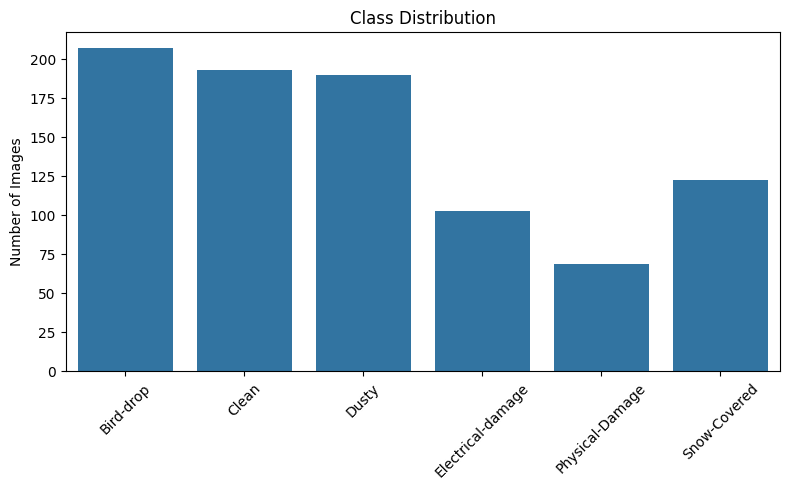

In [ ]:
# Count number of images per class
label_counts = Counter([label for _, label in dataset])
label_names = [class_names[i] for i in label_counts.keys()]

plt.figure(figsize=(8, 5))
sns.barplot(x=label_names, y=list(label_counts.values()))
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


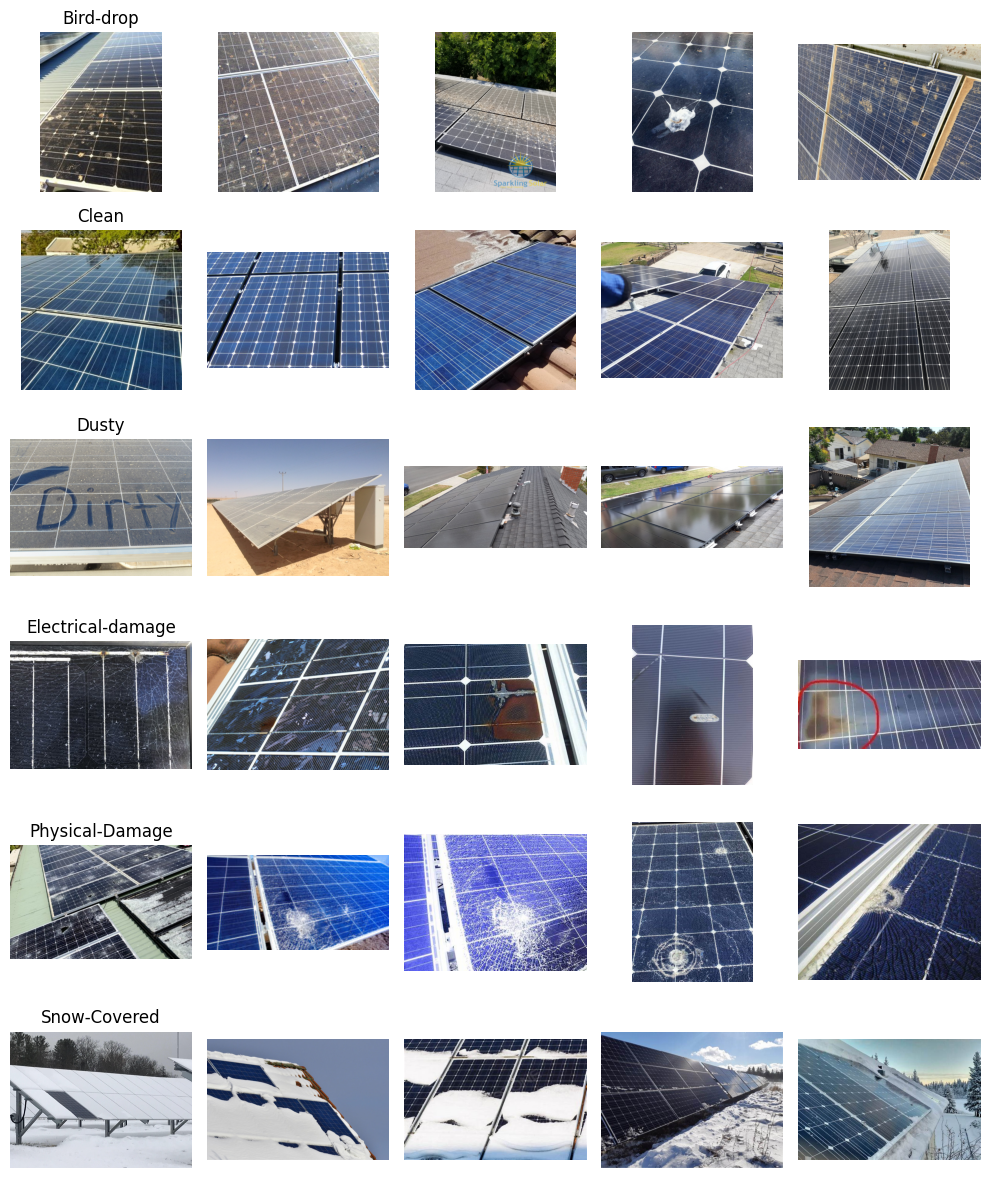

In [ ]:
def show_images(dataset, class_names, n=5):
    fig, axs = plt.subplots(len(class_names), n, figsize=(n*2, len(class_names)*2))
    for class_idx, class_name in enumerate(class_names):
        class_images = [img for img, label in dataset if label == class_idx][:n]
        for i in range(n):
            axs[class_idx, i].imshow(class_images[i])
            axs[class_idx, i].axis('off')
            if i == 0:
                axs[class_idx, i].set_title(class_name)
    plt.tight_layout()
    plt.show()

show_images(dataset, class_names, n=5)


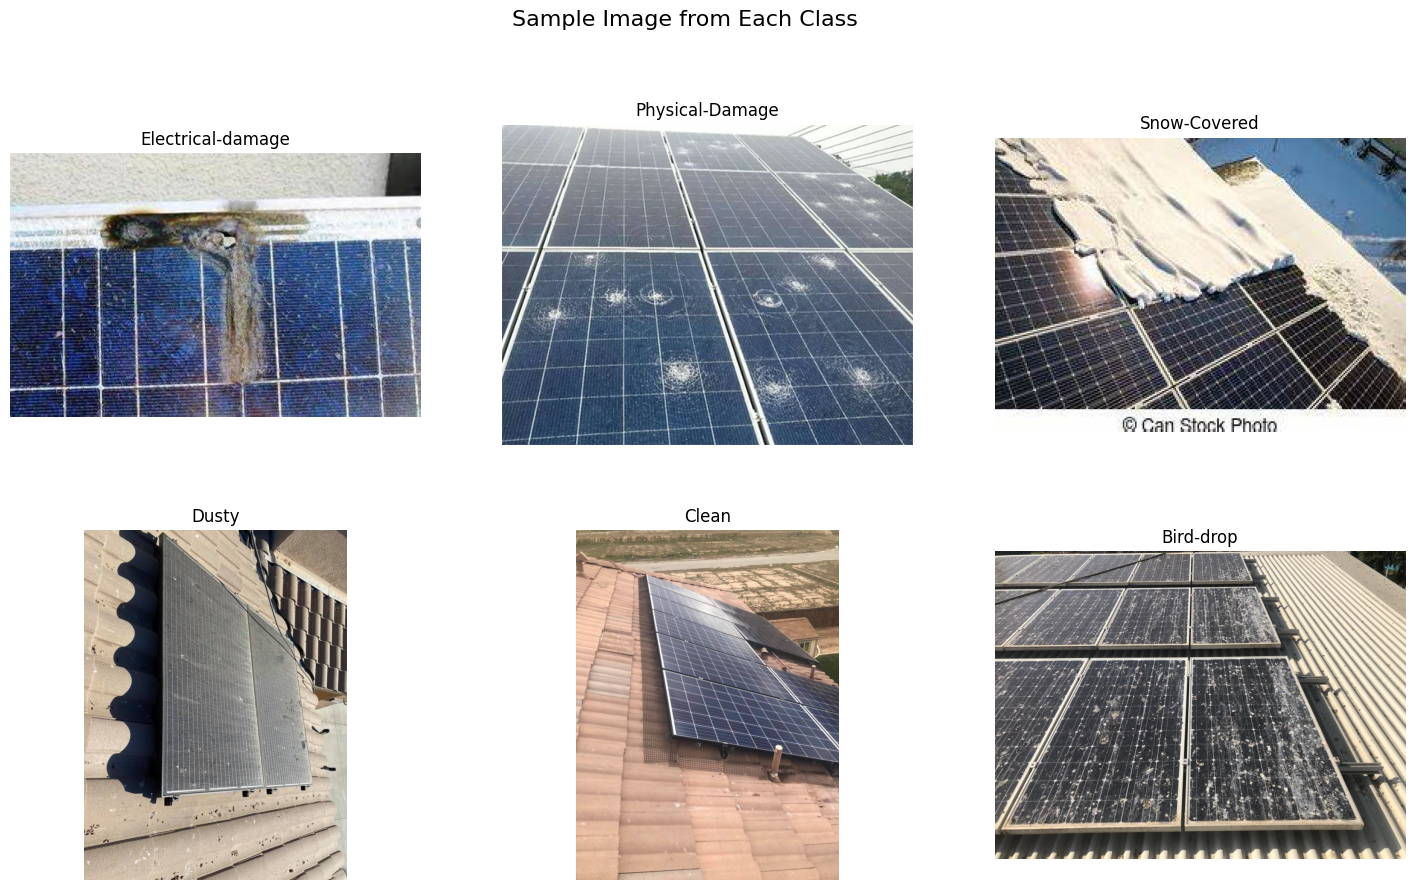

In [ ]:
classes = os.listdir(dataset_path)

plt.figure(figsize=(18, 10))

for i, label in enumerate(classes):
    class_path = os.path.join(dataset_path, label)
    sample_image = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_image)
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.suptitle("Sample Image from Each Class", fontsize=16)
plt.show()


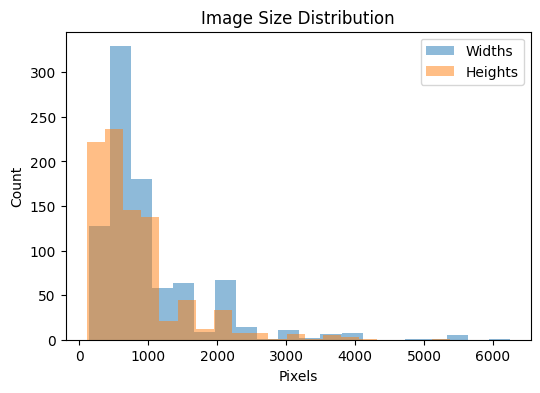

In [ ]:
image_shapes = [Image.open(path[0]).size for path in dataset.samples]
widths, heights = zip(*image_shapes)

plt.figure(figsize=(6, 4))
plt.hist(widths, bins=20, alpha=0.5, label='Widths')
plt.hist(heights, bins=20, alpha=0.5, label='Heights')
plt.legend()
plt.title("Image Size Distribution")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.show()


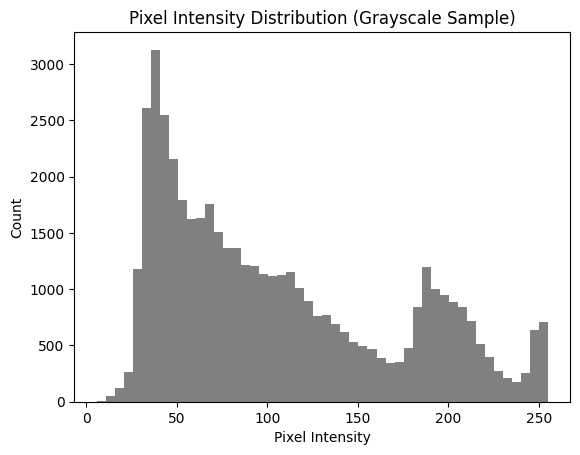

In [ ]:
image = Image.open(dataset.samples[0][0]).convert('L')  # Grayscale
pixels = np.array(image).flatten()

plt.hist(pixels, bins=50, color='gray')
plt.title("Pixel Intensity Distribution (Grayscale Sample)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Count")
plt.show()
